<a href="https://colab.research.google.com/github/GiannisAnte/credit-scoring-case/blob/main/credit_scoring_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install catboost shap -q
!pip install pandas -q

!pip install phik -q

In [4]:
!pip install --pre -U pycaret -q

In [5]:
!pip install -q shap

In [4]:
!wget -q https://raw.githubusercontent.com/jalajthanaki/credit-risk-modelling/master/data/cs-training.csv

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cs-training.csv", index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Описание признаков

150 000 заёмщиков, задача бинарной классификации: предсказать дефолт в течение 2 лет.

| Колонка | Описание |
|---|---|
| `SeriousDlqin2yrs` | **Целевая переменная.** 1 — заёмщик вышел на просрочку 90+ дней в течение 2 лет (дефолт), 0 — нет |
| `RevolvingUtilizationOfUnsecuredLines` | Утилизация возобновляемых необеспеченных кредитных линий (кредитки, овердрафты) — отношение текущего долга к лимиту |
| `age` | Возраст заёмщика |
| `NumberOfTime30-59DaysPastDueNotWorse` | Сколько раз за 2 года была просрочка 30-59 дней (но не хуже) |
| `DebtRatio` | Долговая нагрузка: (платежи по долгам + алименты + расходы на жильё) / месячный доход |
| `MonthlyIncome` | Месячный доход |
| `NumberOfOpenCreditLinesAndLoans` | Количество открытых кредитных линий и займов (кредитки + кредиты на авто, ипотеку и т.д.) |
| `NumberOfTimes90DaysLate` | Сколько раз была просрочка 90+ дней (самая тяжёлая категория) |
| `NumberRealEstateLoansOrLines` | Количество ипотек/кредитов под залог недвижимости |
| `NumberOfTime60-89DaysPastDueNotWorse` | Сколько раз была просрочка 60-89 дней |
| `NumberOfDependents` | Количество иждивенцев (не считая самого заёмщика) |

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


**LOAD TO SQLITE, check with first request**

In [7]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("borrowers", conn, index=True, index_label="borrower_id", if_exists="replace")

150000

In [8]:
query = """
SELECT
    AVG(age) AS avg_age,
    AVG(SeriousDlqin2yrs) AS default_rate,
    COUNT(*) AS n_borrowers
FROM borrowers
"""
result = pd.read_sql(query, conn)
result

,avg_age,default_rate,n_borrowers
0,52.295207,0.06684,150000


# Небольшая справочная таблица с возрастными диапазонами

In [9]:
age_bands = pd.DataFrame({
    "band_id": [1, 2, 3, 4, 5],
    "age_from": [18, 30, 45, 60, 75],
    "age_to":   [29, 44, 59, 74, 120],
    "age_band": ["18-29", "30-44", "45-59", "60-74", "75+"],
})
age_bands.to_sql("age_bands", conn, index=False, if_exists="replace")

5

In [10]:
join_query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
result = pd.read_sql(join_query, conn)
result

,borrower_id,age,age_band,MonthlyIncome
0,1,45,45-59,9120.0
1,2,40,30-44,2600.0
2,3,38,30-44,3042.0
3,4,30,30-44,3300.0
4,5,49,45-59,63588.0
...,...,...,...,...
149994,149996,74,60-74,2100.0
149995,149997,44,30-44,5584.0
149996,149998,58,45-59,NaN
149997,149999,30,30-44,5716.0


In [11]:
#ИЩЕМ АНОМАЛЬНОГО ЗАЕМЩИКА (В ПРЕДЫДУЩЕМ JOIN НЕТ ОДНОЙ ЗАПИСИ)
query = """
SELECT *
FROM borrowers
WHERE age < 18
"""
anomaly = pd.read_sql(query, conn)
anomaly

,borrower_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


JOIN вернул 149,999 строк вместо ожидаемых 150,000. Это позволило обнаружить запись с age=0, которая не попала ни в один возрастной диапазон.

# SQL: сравниваем доход внутри возрастной **группы**
- Выше сделали join с таблицей `age_bands` -  узнали возрастную группу каждого заёмщика
- Дальше нужно **отдельно внутри каждой возрастной группы** отсортировать людей
   по доходу и присвоить каждому номер места - 1-й, 2-й, 3-й и так далее.

In [12]:
query = """
SELECT
    b.borrower_id,
    b.age,
    ab.age_band,
    b.MonthlyIncome,
    RANK() OVER (PARTITION BY ab.age_band ORDER BY b.MonthlyIncome DESC) AS income_rank_in_age_band
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
"""
group_query = pd.read_sql(query, conn)
group_query

,borrower_id,age,age_band,MonthlyIncome,income_rank_in_age_band
0,36716,29,18-29,159791.0,1
1,57095,28,18-29,82083.0,2
2,79710,28,18-29,50000.0,3
3,76219,26,18-29,43000.0,4
4,76231,25,18-29,36000.0,5
...,...,...,...,...,...
149994,149855,75,75+,NaN,7650
149995,149916,76,75+,NaN,7650
149996,149919,77,75+,NaN,7650
149997,149977,76,75+,NaN,7650


**Вывод:**
Оконная функция `RANK()` корректно проставила место по доходу внутри
каждой возрастной группы; в группе 75+ видно, что у заёмщиков с пропущенным
доходом (NaN) всем присвоен одинаковый последний ранг - сигнал,
что `MonthlyIncome` нужно будет почистить перед обучением

## SQL: доля дефолтов по возрастным группам

В какой возрастной группе заёмщики чаще всего уходят в дефолт?
Для этого нужно **сгруппировать** всех заёмщиков по возрастной группе и
посчитать для каждой группы среднюю долю дефолтов (это `GROUP BY`),
а слабые группы с маленьким числом наблюдений - отбросить, чтобы не путать
случайный шум с реальным сигналом (`HAVING COUNT(*) > ...`).

In [13]:
query = """
SELECT
    ab.age_band,
    COUNT(*) AS n_borrowers,
    AVG(b.SeriousDlqin2yrs) AS default_rate
FROM borrowers b
JOIN age_bands ab
    ON b.age BETWEEN ab.age_from AND ab.age_to
GROUP BY ab.age_band
HAVING COUNT(*) > 100
"""
default_rate_query = pd.read_sql(query, conn)
default_rate_query

,age_band,n_borrowers,default_rate
0,18-29,8820,0.117347
1,30-44,38982,0.094916
2,45-59,53879,0.070361
3,60-74,36948,0.034400
4,75+,11370,0.020141


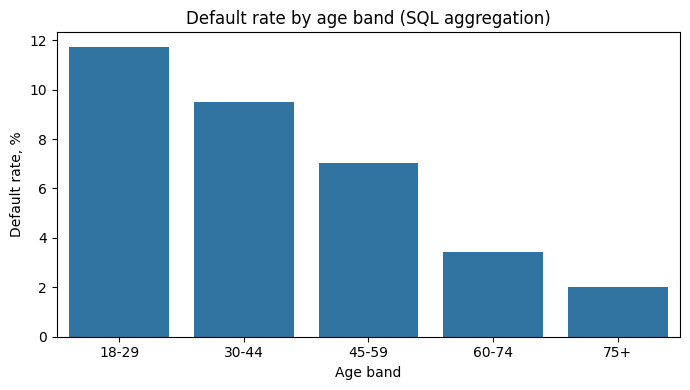

In [14]:
default_rate_query["default_rate_pct"] = default_rate_query["default_rate"] * 100

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=default_rate_query, x="age_band", y="default_rate_pct", ax=ax)
ax.set_title("Default rate by age band (SQL aggregation)")
ax.set_ylabel("Default rate, %")
ax.set_xlabel("Age band")
plt.tight_layout()
plt.show()

**Вывод**: чем старше заёмщик, тем реже он уходит в дефолт. У самых молодых (18–29 лет) дефолт случается в 11.7% случаев, а у самых старших (75+) — только в 2.0%.

# EDA

In [15]:
df = pd.read_sql("SELECT * FROM borrowers", conn, index_col="borrower_id")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [17]:
missing = pd.DataFrame({"count": df.isna().sum(),"percent": df.isna().mean() * 100})

missing

,count,percent
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
MonthlyIncome,29731,19.820667
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## Удаление аномальной записи (age=0)

Проверили запись с `age=0` вручную - независимо от значений остальных
признаков, возраст 0 физически недостоверен. Это единственная такая строка
из 150 000, поэтому удаление не повлияет на статистику модели - удаляем.

In [19]:
df = df[df["age"] > 0]

## Пропуски в MonthlyIncome
Около 20% значений пропущено. Удалять столько строк нельзя, поэтому заполняем пропуски медианой. Она лучше среднего подходит для дохода, потому что меньше зависит от больших значений и выбросов. Дополнительно создадим отдельный признак, показывающий, что доход был пропущен - возможно, сам факт отсутствия этой информации связан с риском дефолта.


In [20]:
df["MonthlyIncome_was_missing"] = df["MonthlyIncome"].isna().astype(int)
# df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

**Не заполняем медианой прямо здесь.** Если посчитать медиану по всему датасету,
включая те строки, что позже попадут в test - будет утечка.

Поэтому здесь создаём только индикатор пропуска (`MonthlyIncome_was_missing`) — это просто факт
"было ли значение пропущено в исходных данных", а не статистика, посчитанная по выборке, поэтому
её можно закрепить до split без риска. Саму медиану посчитаем и применим только после
разделения на train/val/test, и только на основе train.

### Пропуски в NumberOfDependents

Около 2.6% значений пропущено. Сначала проверим, отличается ли уровень дефолтов у клиентов с пропущенным значением от клиентов, у которых число иждивенцев указано. Если разница небольшая, для простоты заменим пропуски на 0.


In [21]:
print("Пропущено:", df[df["NumberOfDependents"].isna()]["SeriousDlqin2yrs"].mean())
print("Не пропущено:", df[df["NumberOfDependents"].notna()]["SeriousDlqin2yrs"].mean())

Пропущено: 0.04561671763506626
Не пропущено: 0.06741057675851446


Проверим, связан ли сам факт пропуска с дефолтом.

Гипотезы:

* H0: наличие пропуска в NumberOfDependents не связано с дефолтом.
* H1: наличие пропуска в NumberOfDependents связано с дефолтом.

Для проверки используем χ²-тест независимости.

In [22]:
temp_t = pd.crosstab(
    df["NumberOfDependents"].isna(),
    df["SeriousDlqin2yrs"]
)
temp_t

SeriousDlqin2yrs,0,1
NumberOfDependents,,
False,136228,9847
True,3745,179


In [23]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(temp_t)

print("chi2:", chi2)
print("p-value:", p_value)

chi2: 28.75140658613835
p-value: 8.229013222139592e-08


Получили:

* χ² = 28.75
* p-value = 8.23 × 10⁻⁸

Пропуски в `NumberOfDependents` заменяем на 0 и дополнительно сохраняем бинарный индикатор `NumberOfDependents_missing`.

Такой подход позволяет модели отдельно учитывать само значение признака и факт отсутствия исходного значения. Проверка связи пропусков с target использовалась только как часть EDA, а не для оценки качества модели на test set.


In [24]:
df["NumberOfDependents_missing"] = df["NumberOfDependents"].isna().astype(int)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149999.0,6.048472,249.756203,0.0,0.029867,0.154176,0.559044,50708.0
age,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149999.0,0.421029,4.192795,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,149999.0,353.007426,2037.825113,0.0,0.175074,0.366503,0.868257,329664.0
MonthlyIncome,120268.0,6670.226810,14384.733888,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149999.0,0.265975,4.169318,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149999.0,0.240388,4.155193,0.0,0.000000,0.000000,0.000000,98.0


# RevolvingUtilizationOfUnsecuredLines

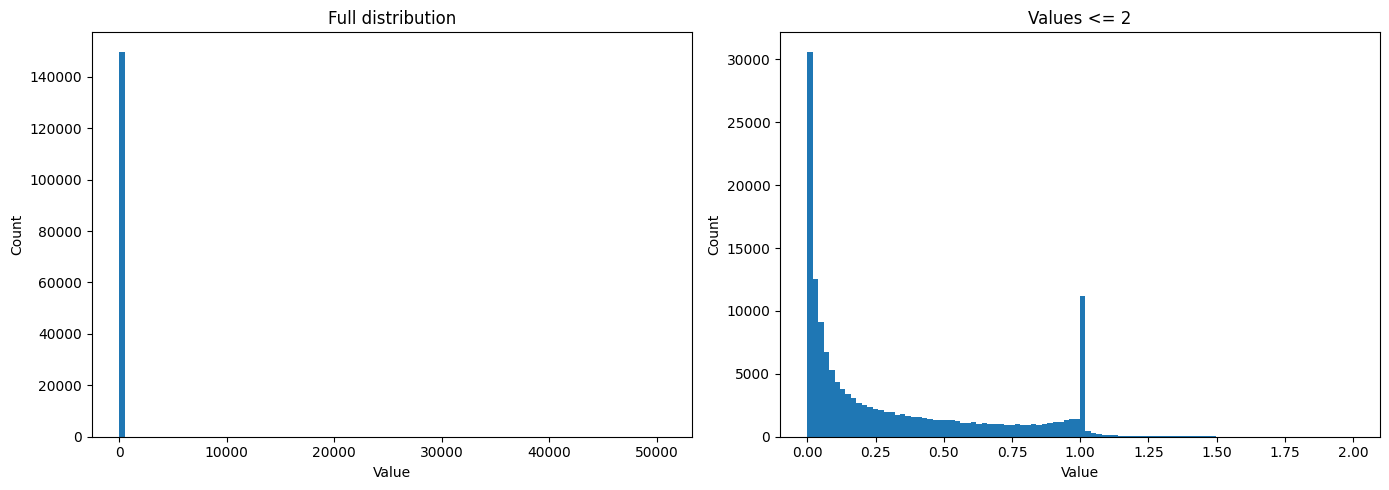

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Полное распределение
axes[0].hist(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=100
)
axes[0].set_title("Full distribution")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Основная масса значений
axes[1].hist(
    df.loc[
        df["RevolvingUtilizationOfUnsecuredLines"] <= 2,
        "RevolvingUtilizationOfUnsecuredLines"
    ],
    bins=100
)
axes[1].set_title("Values <= 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [27]:
#Проверяем, какая доля наблюдений находится в хвосте
for threshold in [1, 2, 5, 10, 100]:
    count = (df["RevolvingUtilizationOfUnsecuredLines"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

df["RevolvingUtilizationOfUnsecuredLines"].quantile(
    [0.95, 0.99, 0.995, 0.999]
)

>1: 3321 (2.21%)
>2: 371 (0.25%)
>5: 254 (0.17%)
>10: 241 (0.16%)
>100: 223 (0.15%)


,RevolvingUtilizationOfUnsecuredLines
0.950,1.000000
0.990,1.092958
0.995,1.366279
0.999,1571.012000


In [28]:
#Отдельно смотрим только значения выше 1
df.loc[
    df["RevolvingUtilizationOfUnsecuredLines"] > 1,
    "RevolvingUtilizationOfUnsecuredLines"
].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).T

,RevolvingUtilizationOfUnsecuredLines
count,3321.000000
mean,259.773362
std,1659.034074
min,1.000059
50%,1.074633
90%,2.197674
95%,1090.000000
99%,6723.000000
99.9%,21524.480000
max,50708.000000


In [29]:
#Разбиваем значения на несколько диапазонов и сравниваем их с default rate
df["util_group"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-float("inf"), 1, 2, 10, 100, float("inf")],
    labels=["<=1", "1-2", "2-10", "10-100", ">100"]
)

df.groupby("util_group", observed=True)["SeriousDlqin2yrs"].agg(
    ["count", "mean"]
)

,count,mean
util_group,,
<=1,146678,0.059920
1-2,2950,0.401017
2-10,130,0.284615
10-100,18,0.333333
>100,223,0.049327


In [30]:
import numpy as np
# Сильно скошенные значения сжимаем логарифмом, диагностический столбец больше не нужен
df["RevolvingUtilization_log"] = np.log1p(
    df["RevolvingUtilizationOfUnsecuredLines"]
)
df.drop(columns="util_group", inplace=True)

# AGE

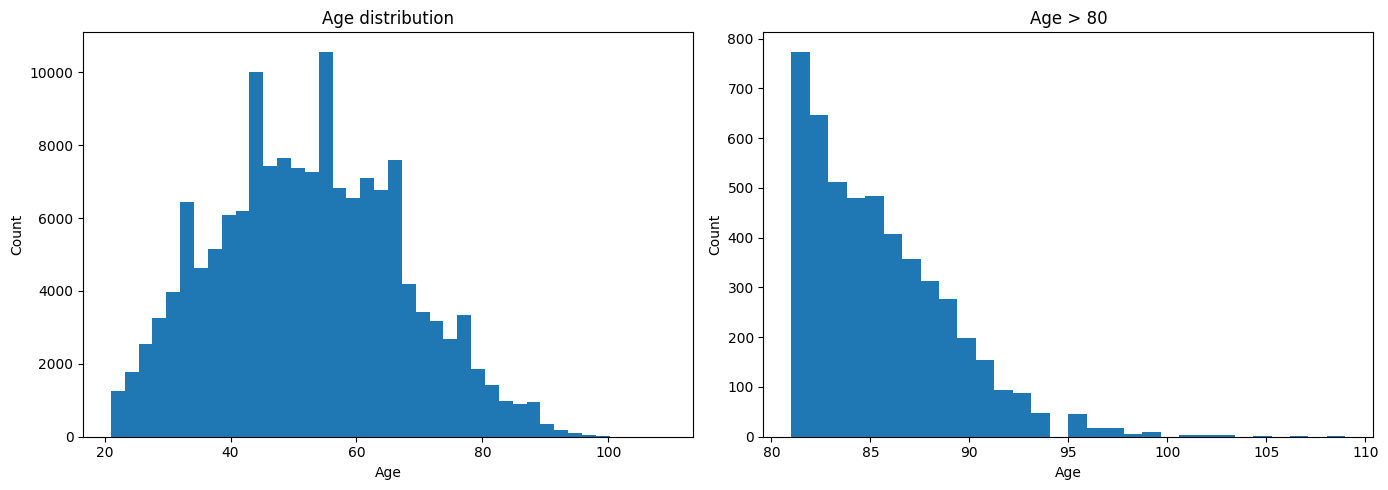

In [31]:
#Смотрим распределение возраста и проверяем крайние значения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=40)
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["age"] > 80, "age"],
    bins=30
)
axes[1].set_title("Age > 80")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [32]:
print("Age > 100:", (df["age"] > 100).sum())
print("Maximum age:", df["age"].max())

Age > 100: 13
Maximum age: 109


# NumberOfTime30-59DaysPastDueNotWorse

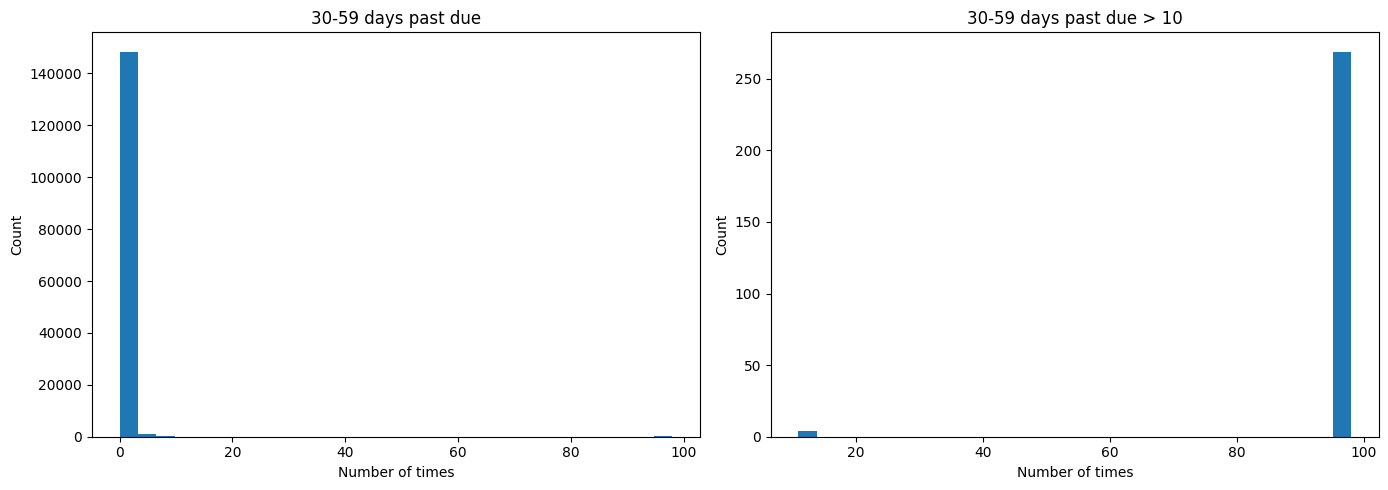

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(
    df["NumberOfTime30-59DaysPastDueNotWorse"],
    bins=30
)
axes[0].set_title("30-59 days past due")
axes[0].set_xlabel("Number of times")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[
        df["NumberOfTime30-59DaysPastDueNotWorse"] > 10,
        "NumberOfTime30-59DaysPastDueNotWorse"
    ],
    bins=30
)
axes[1].set_title("30-59 days past due > 10")
axes[1].set_xlabel("Number of times")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [34]:
#Проверяем самые частые значения и подозрительное значение 98
print(
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    .value_counts()
    .sort_index()
    .tail(15)
)

NumberOfTime30-59DaysPastDueNotWorse
1     16032
2      4598
3      1754
4       747
5       342
6       140
7        54
8        25
9        12
10        4
11        1
12        2
13        1
96        5
98      264
Name: count, dtype: int64


In [35]:
#Проверяем три признака просрочек: в них встречаются одинаковые аномальные значения
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_cols:
    print(
        col,
        "96:", (df[col] == 96).sum(),
        "98:", (df[col] == 98).sum()
    )

NumberOfTime30-59DaysPastDueNotWorse 96: 5 98: 264
NumberOfTime60-89DaysPastDueNotWorse 96: 5 98: 264
NumberOfTimes90DaysLate 96: 5 98: 264


In [36]:
#Обрабатываем одинаковые аномальные значения во всех признаках просрочек
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delinq_cols:
    #Сохраняем информацию о наличии аномального значения
    df[col + "_missing"] = df[col].isin([96, 98]).astype(int)

    #Заменяем аномальные значения на пропуски
    df[col] = df[col].replace([96, 98], np.nan)

    #Для количества просрочек используем 0 как простое значение после очистки
    df[col] = df[col].fillna(0)

In [37]:
# Проверяем, что аномальных значений больше нет
for col in delinq_cols:
    print(col, "96:", (df[col] == 96).sum(), "98:", (df[col] == 98).sum())

NumberOfTime30-59DaysPastDueNotWorse 96: 0 98: 0
NumberOfTime60-89DaysPastDueNotWorse 96: 0 98: 0
NumberOfTimes90DaysLate 96: 0 98: 0


### Признаки просрочек

В трёх признаках просрочек обнаружены аномальные значения 96 и 98. Они заменены на пропуски, при этом добавлен отдельный индикатор их наличия. После этого пропуски заполнены значением 0.


# DebtRatio

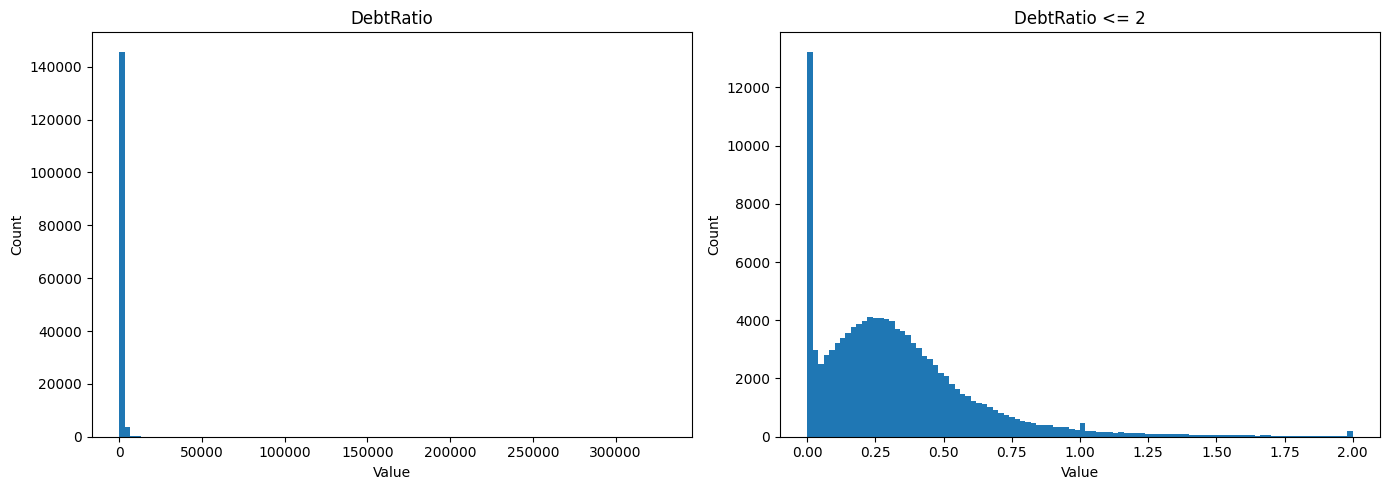

In [38]:
#Проверяем распределение DebtRatio и его длинный хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["DebtRatio"],
    bins=100
)
axes[0].set_title("DebtRatio")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["DebtRatio"] <= 2, "DebtRatio"],
    bins=100
)
axes[1].set_title("DebtRatio <= 2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [39]:
#Проверяем, насколько много экстремальных значений
for threshold in [1, 2, 5, 10, 100]:
    count = (df["DebtRatio"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

>1: 35137 (23.42%)
>2: 31045 (20.70%)
>5: 29646 (19.76%)
>10: 28877 (19.25%)
>100: 24380 (16.25%)


In [40]:
#DebtRatio имеет очень длинный правый хвост, поэтому добавляем лог-преобразование
df["DebtRatio_log"] = np.log1p(df["DebtRatio"])

In [41]:
#Проверяем распределение после лог-преобразования
df["DebtRatio_log"].describe()

,DebtRatio_log
count,149999.000000
mean,1.525182
std,2.627244
min,0.000000
25%,0.161331
50%,0.312255
75%,0.625006
max,12.705832



`DebtRatio` имеет сильно скошенное распределение и длинный правый хвост. Значения напрямую не удаляли, так как они занимают значительную долю выборки. Для уменьшения влияния экстремальных значений добавили логарифмическое преобразование `DebtRatio_log`.


# MonthlyIncome

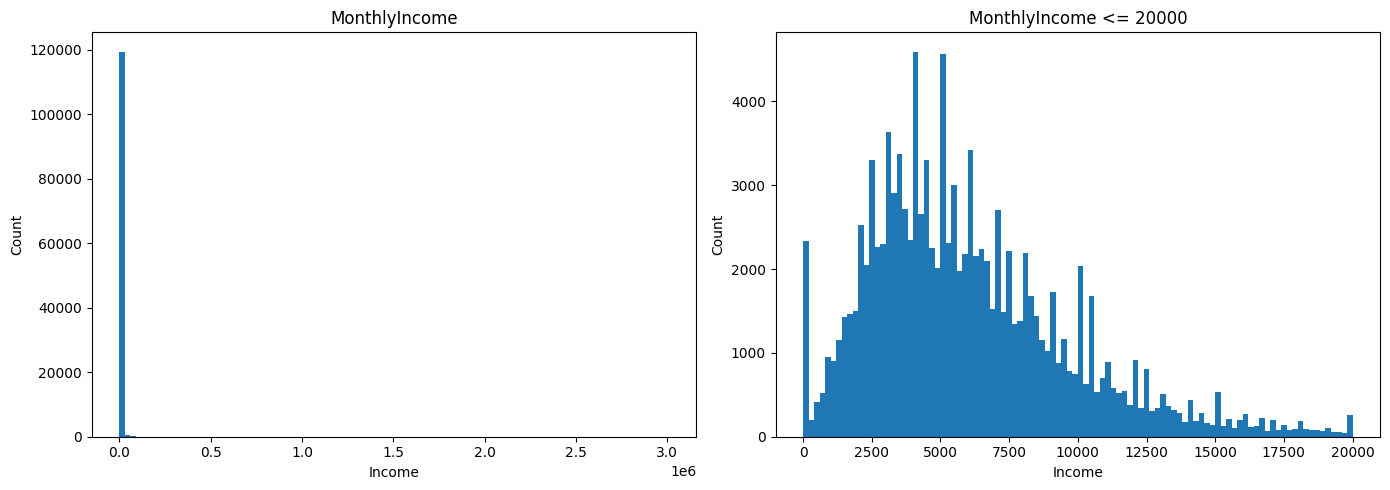

>10000: 18319 (12.21%)
>20000: 2103 (1.40%)
>50000: 301 (0.20%)
>100000: 70 (0.05%)


In [42]:
#Смотрим распределение дохода и его длинный хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["MonthlyIncome"],
    bins=100
)
axes[0].set_title("MonthlyIncome")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Count")

axes[1].hist(
    df.loc[df["MonthlyIncome"] <= 20000, "MonthlyIncome"],
    bins=100
)
axes[1].set_title("MonthlyIncome <= 20000")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост дохода
for threshold in [10000, 20000, 50000, 100000]:
    count = (df["MonthlyIncome"] > threshold).sum()
    percent = count / len(df) * 100
    print(f">{threshold}: {count} ({percent:.2f}%)")

В MonthlyIncome наблюдается выраженный правый хвост. Импутацию и логарифмическое преобразование выполняем после train/validation/test split, используя статистики только train.

# NumberOfOpenCreditLinesAndLoans

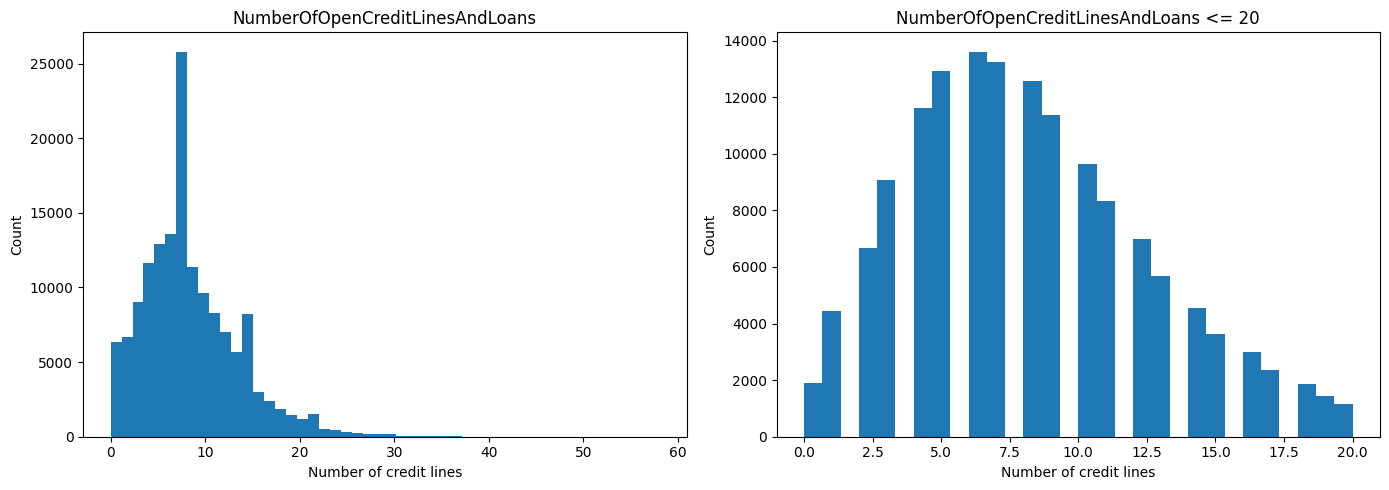

>10: 43010 (28.67%)
>20: 3980 (2.65%)
>30: 354 (0.24%)
>40: 62 (0.04%)
>50: 15 (0.01%)


In [43]:
#Смотрим распределение количества открытых кредитных линий и его хвост
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["NumberOfOpenCreditLinesAndLoans"],
    bins=50
)

axes[0].set_title("NumberOfOpenCreditLinesAndLoans")
axes[0].set_xlabel("Number of credit lines")
axes[0].set_ylabel("Count")


axes[1].hist(
    df.loc[
        df["NumberOfOpenCreditLinesAndLoans"] <= 20,
        "NumberOfOpenCreditLinesAndLoans"
    ],
    bins=30
)

axes[1].set_title("NumberOfOpenCreditLinesAndLoans <= 20")
axes[1].set_xlabel("Number of credit lines")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост
for threshold in [10, 20, 30, 40, 50]:

    count = (
        df["NumberOfOpenCreditLinesAndLoans"] > threshold
    ).sum()

    percent = count / len(df) * 100

    print(f">{threshold}: {count} ({percent:.2f}%)")

Признак имеет правый хвост, однако экстремальные значения встречаются редко: только 0.24% наблюдений имеют более 30 открытых кредитных линий. Оснований считать значения аномальными нет, поэтому признак оставили без изменений.

# NumberRealEstateLoansOrLines

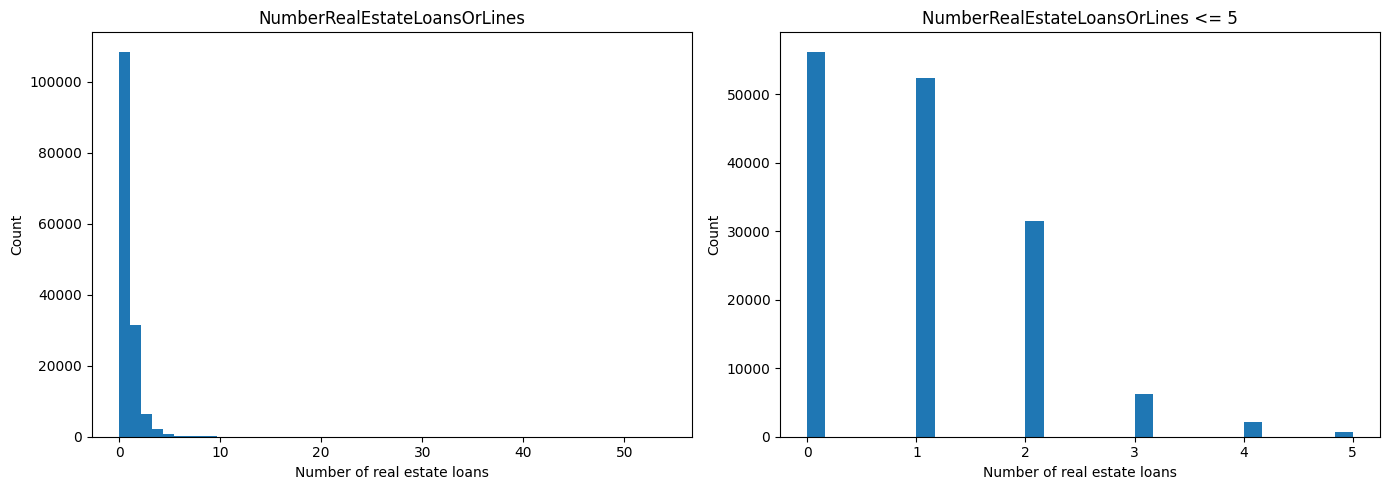

>2: 9952 (6.63%)
>5: 793 (0.53%)
>10: 94 (0.06%)
>20: 10 (0.01%)
>30: 2 (0.00%)


In [44]:
# Смотрим распределение количества ипотечных и других кредитов, связанных с недвижимостью
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["NumberRealEstateLoansOrLines"],
    bins=50
)

axes[0].set_title("NumberRealEstateLoansOrLines")
axes[0].set_xlabel("Number of real estate loans")
axes[0].set_ylabel("Count")


axes[1].hist(
    df.loc[
        df["NumberRealEstateLoansOrLines"] <= 5,
        "NumberRealEstateLoansOrLines"
    ],
    bins=30
)

axes[1].set_title("NumberRealEstateLoansOrLines <= 5")
axes[1].set_xlabel("Number of real estate loans")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Проверяем верхний хвост
for threshold in [2, 5, 10, 20, 30]:

    count = (
        df["NumberRealEstateLoansOrLines"] > threshold
    ).sum()

    percent = count / len(df) * 100

    print(f">{threshold}: {count} ({percent:.2f}%)")

Признак имеет небольшой правый хвост, но экстремальные значения встречаются крайне редко. Значения свыше 10 наблюдаются только в 0.06% случаев, поэтому оснований считать их аномальными нет. Признак оставили без изменений.

# Финальная проверка качества данных

In [45]:
print("Размер датасета:", df.shape)

print("\nПропуски:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nКоличество пропусков всего:", df.isna().sum().sum())

print("\nТипы данных:")
print(df.dtypes)

print("\nЦелевой признак:")
print(df["SeriousDlqin2yrs"].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True))

print("\nДиапазоны числовых признаков:")
print(df.describe().T[["min", "max"]])

Размер датасета: (149999, 18)

Пропуски:
MonthlyIncome    29731
dtype: int64

Количество пропусков всего: 29731

Типы данных:
SeriousDlqin2yrs                                  int64
RevolvingUtilizationOfUnsecuredLines            float64
age                                               int64
NumberOfTime30-59DaysPastDueNotWorse            float64
DebtRatio                                       float64
MonthlyIncome                                   float64
NumberOfOpenCreditLinesAndLoans                   int64
NumberOfTimes90DaysLate                         float64
NumberRealEstateLoansOrLines                      int64
NumberOfTime60-89DaysPastDueNotWorse            float64
NumberOfDependents                              float64
MonthlyIncome_was_missing                         int64
NumberOfDependents_missing                        int64
RevolvingUtilization_log                        float64
NumberOfTime30-59DaysPastDueNotWorse_missing      int64
NumberOfTime60-89DaysPastDueNotWor

После проведения EDA и preprocessing датасет подготовлен к моделированию. Пропуски обработаны, аномальные значения в признаках просрочек скорректированы с сохранением индикаторов, для сильно скошенных признаков добавлены логарифмические версии.

Редкие экстремальные значения в остальных признаках не удалялись без достаточных оснований. Диагностические признаки после анализа удалены.

В итоговом датасете 149 999 наблюдений и 18 признаков, пропуски отсутствуют, кроме данных признака MonthlyIncome - его обработаем далее. Доля положительного класса `SeriousDlqin2yrs` составляет 6.68%.


# Смотрим корреляции

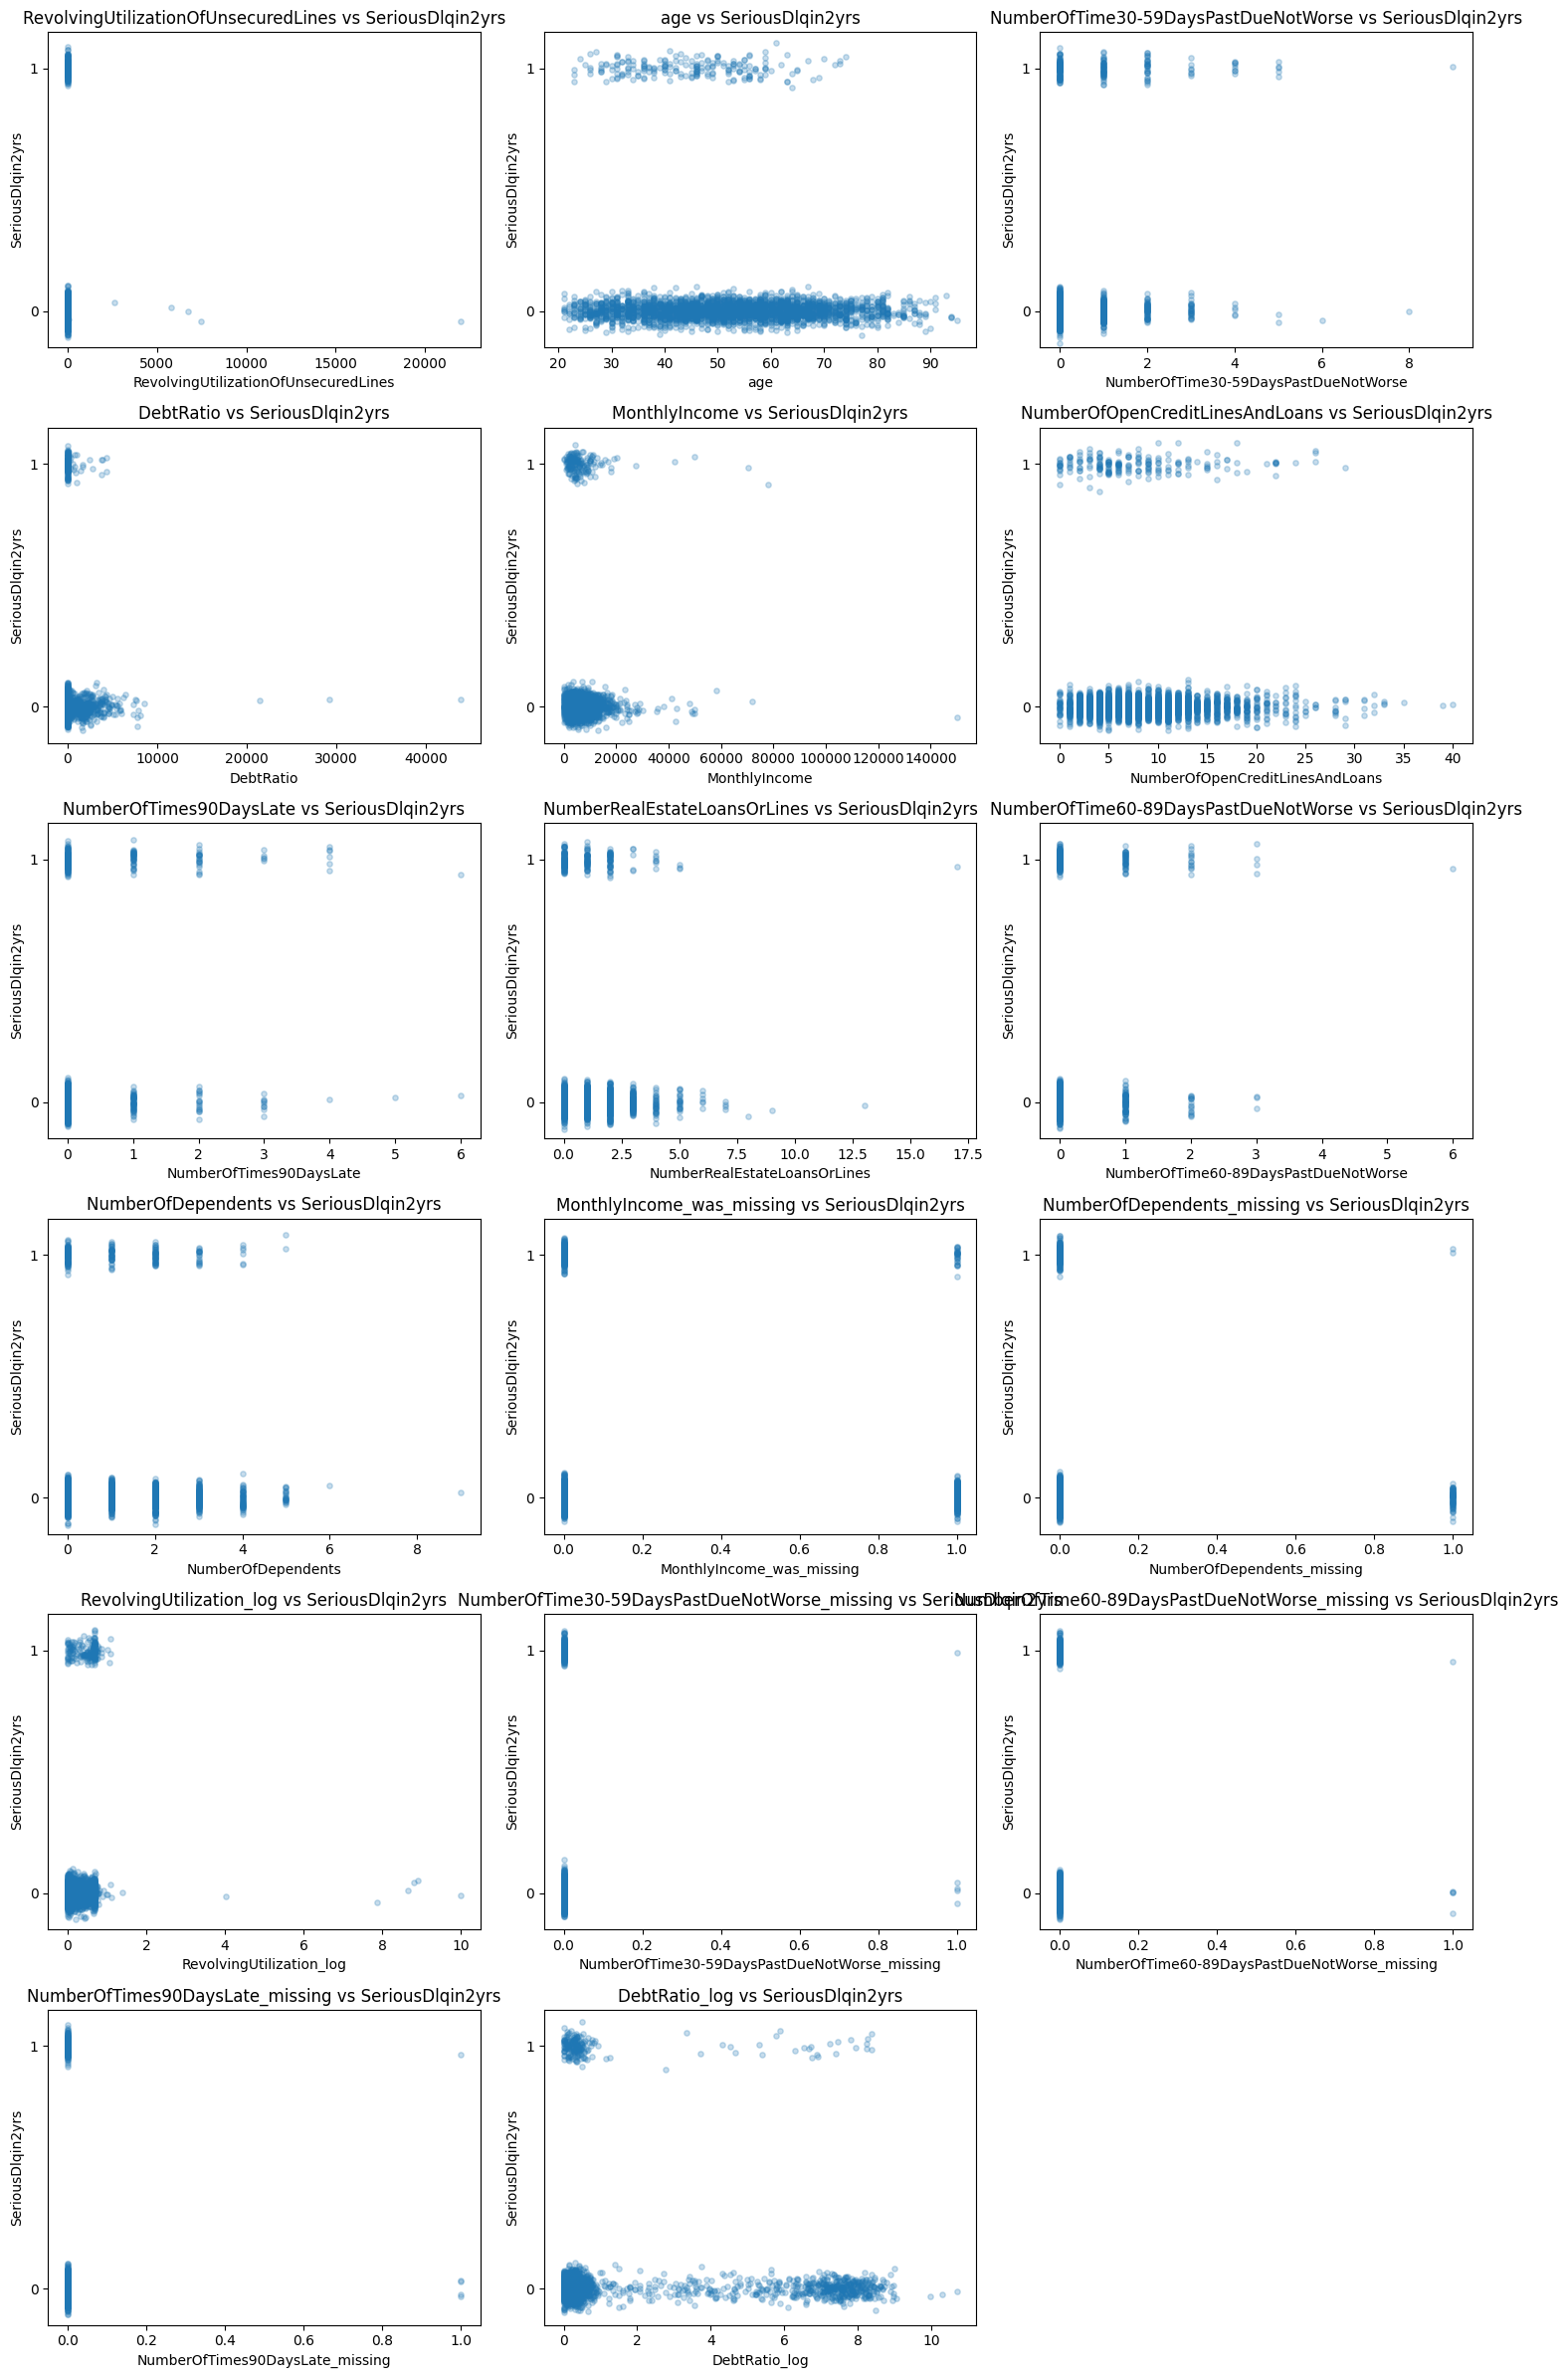

In [46]:
import seaborn as sns
def plot_feature_scatter(df: pd.DataFrame, target: str, sample_size: int = 3000):
    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    numeric_features = df.select_dtypes(include="number").columns.drop(
        target, errors="ignore"
    )

    n_features = len(numeric_features)
    ncols = 3
    nrows = (n_features + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4 * nrows)
    )

    axes = axes.flatten()

    for i, feature in enumerate(numeric_features):
        y_jitter = df[target] + np.random.normal(
            0, 0.03, size=len(df)
        )

        axes[i].scatter(
            df[feature],
            y_jitter,
            alpha=0.25,
            s=15
        )

        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target)
        axes[i].set_title(f"{feature} vs {target}")

        axes[i].set_yticks([0, 1])
        axes[i].set_ylim(-0.15, 1.15)

    for ax in axes[n_features:]:
        ax.remove()

    plt.tight_layout()
    plt.show()


plot_feature_scatter(df, "SeriousDlqin2yrs", 3000)

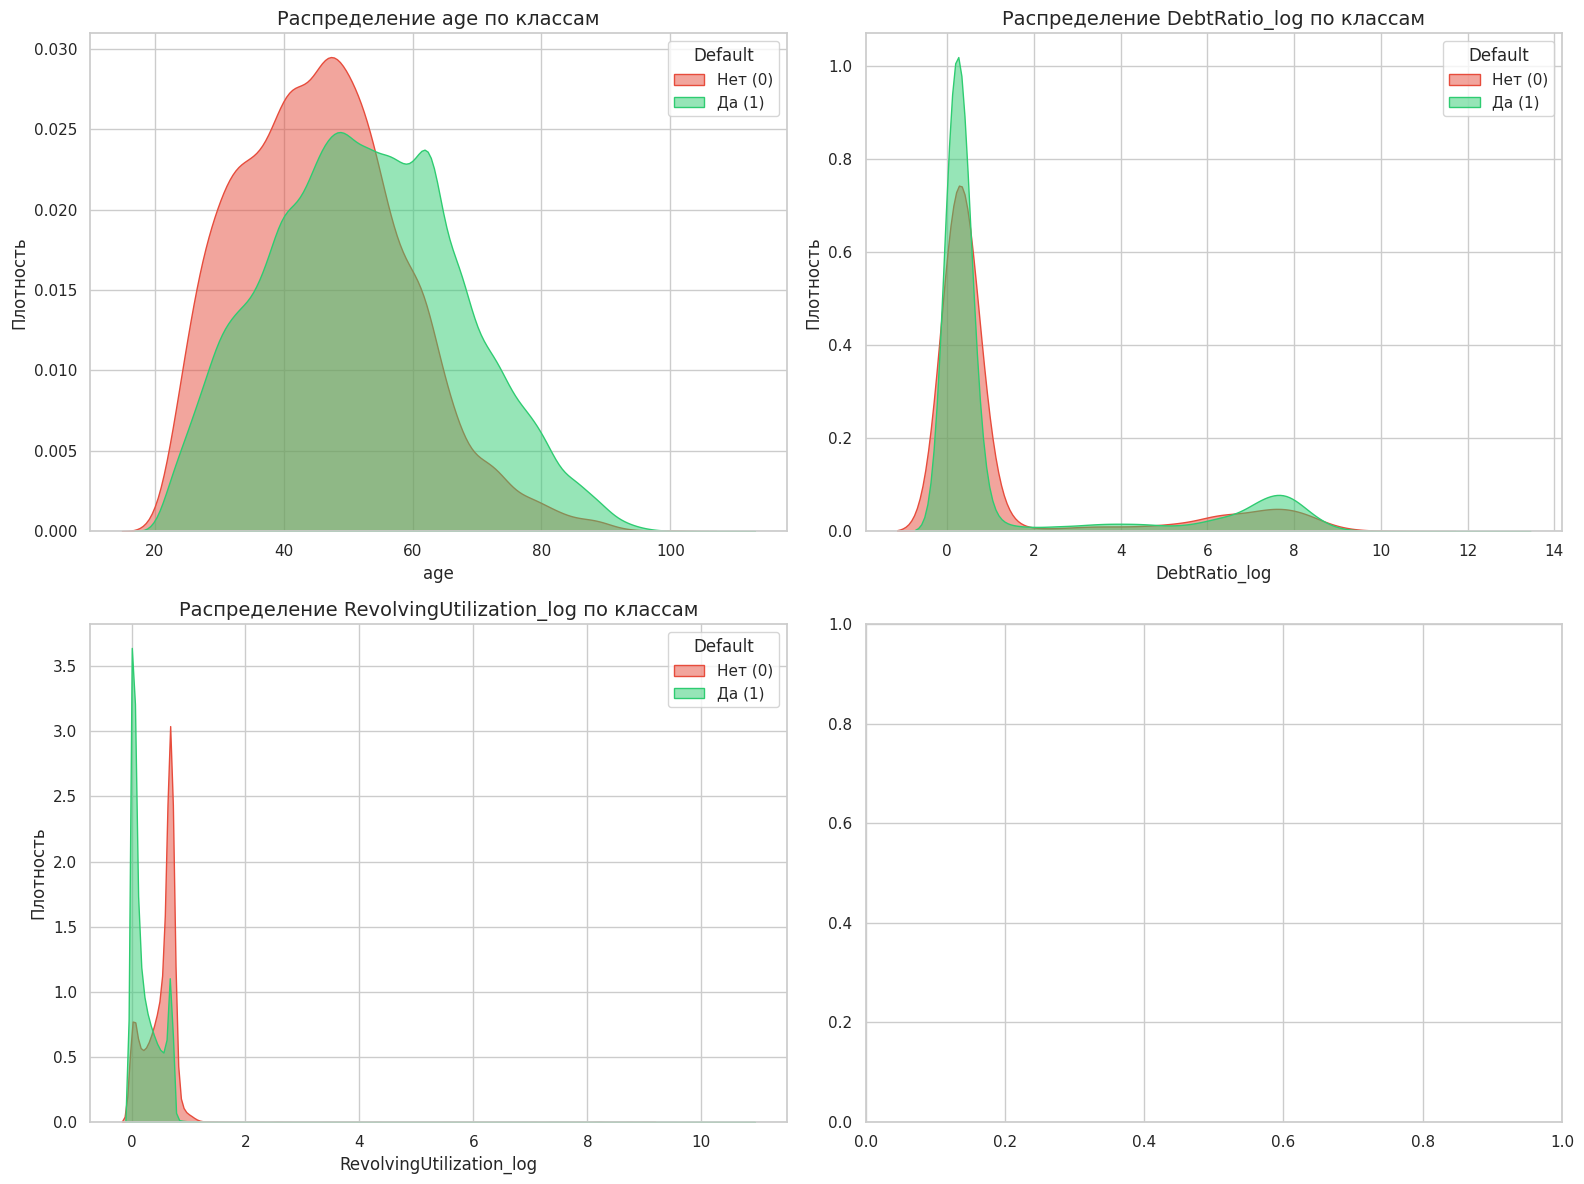

In [85]:
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

target = 'SeriousDlqin2yrs'

continuous_features = [
    'age',
    'DebtRatio_log',
    'RevolvingUtilization_log'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.kdeplot(
        data=df, x=col, hue=target,
        fill=True, common_norm=False,
        palette=['#2ecc71', '#e74c3c'], # Зеленый для 0, Красный для 1
        alpha=0.5, ax=axes[i]
    )
    axes[i].set_title(f'Распределение {col} по классам', fontsize=14)
    axes[i].set_ylabel('Плотность')
    axes[i].legend(title='Default', labels=['Нет (0)', 'Да (1)'])

plt.tight_layout()
plt.show()

interval columns not set, guessing: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_was_missing', 'NumberOfDependents_missing', 'RevolvingUtilization_log', 'NumberOfTime30-59DaysPastDueNotWorse_missing', 'NumberOfTime60-89DaysPastDueNotWorse_missing', 'NumberOfTimes90DaysLate_missing', 'DebtRatio_log', 'SeriousDlqin2yrs']


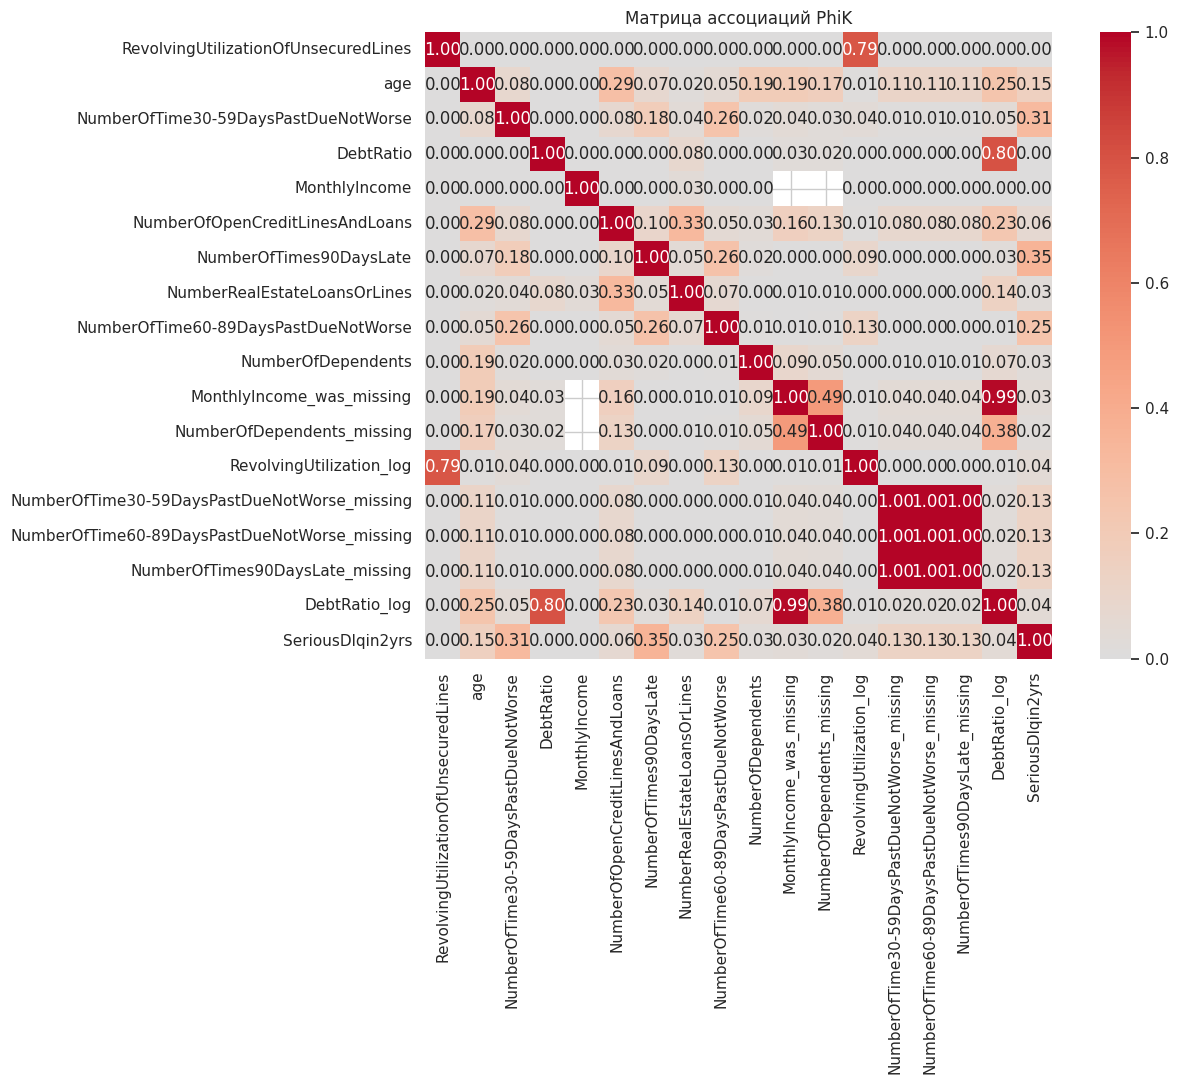

In [86]:
import phik

plot_cols = [c for c in df.columns if c != "SeriousDlqin2yrs"]

phik_matrix = df[plot_cols + ["SeriousDlqin2yrs"]].phik_matrix()

plt.figure(figsize=(14, 11))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Матрица ассоциаций PhiK")
plt.tight_layout()
plt.show()

## Общий вывод по EDA

* **Scatter plots:** из-за бинарного таргета наблюдается overplotting. Видны выбросы в `DebtRatio`, `RevolvingUtilization` и `MonthlyIncome`. Признаки просрочек наиболее заметно разделяют классы.
* **KDE:** `RevolvingUtilization_log` показывает выраженную нелинейную связь с дефолтом. `DebtRatio_log` сохраняет длинный хвост.
* **PhiK:** наиболее сильная связь с таргетом у признаков просрочек: `90DaysLate` - 0.35, `30-59DaysLate` - 0.31, `60-89DaysLate` - 0.25. Исходные признаки и их log-версии имеют высокую взаимную зависимость (0.71–0.80)


# Деление данных и создание фич

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

#откладываем 30% под validation и test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

#temp делим пополам — 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Default rate — train: {y_train.mean():.4f}, "
      f"val: {y_val.mean():.4f}, test: {y_test.mean():.4f}")

Train: (104999, 17), Val: (22500, 17), Test: (22500, 17)
Default rate — train: 0.0668, val: 0.0668, test: 0.0668


# Обрабатываем "MonthlyIncome"

In [65]:
income_median = X_train["MonthlyIncome"].median()
print(f"Train median income: {income_median:.1f}")

for part in (X_train, X_val, X_test):
    part["MonthlyIncome"] = part["MonthlyIncome"].fillna(income_median)
    part["MonthlyIncome_log"] = np.log1p(part["MonthlyIncome"])

Train median income: 5400.0


In [66]:
from pycaret.classification import ClassificationExperiment

train = X_train.copy()
train["SeriousDlqin2yrs"] = y_train

exp = ClassificationExperiment(
    target="SeriousDlqin2yrs",
    session_id=42,
    train_size=0.8,
    fold_strategy='stratifiedkfold',
    fold=5,
    verbose=True
).fit(train)

selected_models = [
    "lr", "dt", "rf", "et", "gbc", "xgboost", "lightgbm", "catboost"
]

best_model = exp.compare_models(
    include=selected_models,
    sort="AUC"
)

[LightGBM] [Info] Number of positive: 4491, number of negative: 62708
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1736
[LightGBM] [Info] Number of data points in the train set: 67199, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066831 -> initscore=-2.636414
[LightGBM] [Info] Start training from score -2.636414
[LightGBM] [Info] Number of positive: 4491, number of negative: 62708
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1735
[LightGBM] [Info] Number of data points in the train set: 67199, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066831 -> initscore=-2.636414
[LightGBM] [Info] Start training from score -2.636414
[LightGBM] [In

In [67]:
results = exp.pull()
results = results.sort_values('AUC', ascending=False).reset_index(drop=True)
results.style.background_gradient(cmap='RdYlGn', subset=['AUC'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,gbc,0.937200,0.864400,0.191000,0.592700,0.288700,0.264800,0.312300
1,catboost,0.936500,0.863700,0.197900,0.574100,0.294100,0.269000,0.311700
2,lightgbm,0.937000,0.862700,0.184900,0.591900,0.281600,0.258000,0.306900
3,xgboost,0.934700,0.853100,0.204000,0.530900,0.294600,0.267400,0.301600
4,rf,0.935900,0.837200,0.181500,0.562600,0.274300,0.249900,0.294600
5,et,0.934900,0.835400,0.176200,0.538800,0.265500,0.240500,0.282400
6,lr,0.936500,0.834200,0.165500,0.587900,0.257900,0.235600,0.288700
7,dt,0.897300,0.612500,0.282500,0.256500,0.268900,0.213800,0.214100


На предварительном этапе PyCaret использовался для быстрого скрининга нескольких алгоритмов на исходных признаках. После feature engineering модели были повторно сравнены на едином наборе из 28 признаков с помощью 5-fold Stratified CV.

При threshold = 0.5 качество обнаружения положительного класса существенно зависит от выбранного компромисса между precision и recall. Поэтому для финальной модели threshold подбирается отдельно на validation по F1, а test используется только для итоговой оценки.


# Функция фичей

In [68]:
def add_features(data):
    data = data.copy()

    # Общее количество просрочек всех типов
    # Бизнес: общий показатель истории проблем с платежами
    data["TotalDelinquencies"] = (
        data["NumberOfTime30-59DaysPastDueNotWorse"]
        + data["NumberOfTime60-89DaysPastDueNotWorse"]
        + data["NumberOfTimes90DaysLate"]
    )

    # Была ли у клиента хотя бы одна просрочка
    # Бизнес: наличие негативной кредитной истории
    data["HasDelinquency"] = (
        data["TotalDelinquencies"] > 0
    ).astype(int)

    # Была ли серьёзная просрочка 90+ дней
    # Бизнес: более сильный индикатор кредитного риска
    data["Has90DaysLate"] = (
        data["NumberOfTimes90DaysLate"] > 0
    ).astype(int)

    # Взвешенная тяжесть просрочек
    # Для дополнительного описания тяжести просрочек был создан эвристический признак DelinquencySeverity. Разным типам просрочки присвоены возрастающие веса:
    # 30–59 дней → 1
    # 60–89 дней → 2
    # 90+ дней → 3
    # Таким образом, признак учитывает не только количество просрочек, но и их условную тяжесть.
    data["DelinquencySeverity"] = (
        data["NumberOfTime30-59DaysPastDueNotWorse"]
        + 2 * data["NumberOfTime60-89DaysPastDueNotWorse"]
        + 3 * data["NumberOfTimes90DaysLate"]
    )

    # Доля кредитов, связанных с недвижимостью
    # Бизнес: структура кредитного портфеля клиента
    data["RealEstateLoansRatio"] = (
        data["NumberRealEstateLoansOrLines"]
        / (data["NumberOfOpenCreditLinesAndLoans"] + 1)
    )

    # Кредиты, не связанные с недвижимостью
    # Бизнес: дополнительная характеристика структуры кредитной нагрузки
    data["NonRealEstateLoans"] = (
        data["NumberOfOpenCreditLinesAndLoans"]
        - data["NumberRealEstateLoansOrLines"]
    )

    # Доход в расчёте на иждивенца
    # Для 0 иждивенцев используем сам доход
    data["IncomePerDependent"] = (
        data["MonthlyIncome"]
        / data["NumberOfDependents"].replace(0, 1)
    )

    # Использование более 100% доступного revolving-кредита
    # Бизнес: признак очень высокой кредитной загрузки
    data["HighUtilization"] = (
        data["RevolvingUtilizationOfUnsecuredLines"] > 1
    ).astype(int)

    # Просрочки × кредитная загрузка
    # Бизнес: сочетание двух факторов повышенного риска
    data["DelinquencyUtilization"] = (
        data["TotalDelinquencies"]
        * data["RevolvingUtilization_log"]
    )

    # Серьёзная просрочка + высокая кредитная загрузка
    # Бизнес: комбинация двух сильных риск-факторов
    data["SevereLateHighUtilization"] = (
        data["Has90DaysLate"]
        * data["HighUtilization"]
    )

    return data

In [69]:
X_train_f = add_features(X_train)
X_val_f = add_features(X_val)
X_test_f = add_features(X_test)
print(f"Train: {X_train_f.shape}, Val: {X_val_f.shape}, Test: {X_test_f.shape}")

Train: (104999, 28), Val: (22500, 28), Test: (22500, 28)


In [70]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    make_scorer, roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix
)

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [71]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [72]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

  "CatBoost":  CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    verbose=False,
    random_seed=42
),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    )
}

In [74]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_f,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC std": scores["test_roc_auc"].std(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "PR-AUC std": scores["test_pr_auc"].std()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,ROC-AUC,ROC-AUC std,PR-AUC,PR-AUC std
0,CatBoost,0.863755,0.004005,0.399010,0.009129
1,LightGBM,0.858036,0.004396,0.388976,0.007624
2,Logistic Regression,0.857519,0.002891,0.356821,0.007154


# Пробуем далее с CatBoost

In [76]:
best_params = {
    "iterations": 1000, "depth": 6, "learning_rate": 0.05,
    "auto_class_weights": "Balanced",
    "loss_function": "Logloss", "eval_metric": "AUC",
    "early_stopping_rounds": 50, "verbose": False, "random_seed": 42
}
best_model = CatBoostClassifier(**best_params)
best_model.fit(X_train_f, y_train, eval_set=(X_val_f, y_val))
print(f"Best iteration: {best_model.get_best_iteration()}")


Best iteration: 272


In [96]:
y_val_proba = best_model.predict_proba(X_val_f)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
f1 = 2 * (precisions * recalls) / (
    precisions + recalls + 1e-9
)

best_idx = f1[:-1].argmax()
best_thr = thresholds[best_idx]

print(f"Best threshold (по F1 на validation): {best_thr:.3f}")
print(f"Val PR-AUC: {average_precision_score(y_val, y_val_proba):.4f}")

Best threshold (по F1 на validation): 0.790
Val PR-AUC: 0.4045


In [97]:
y_test_proba = best_model.predict_proba(X_test_f)[:, 1]

print("\n" + "=" * 60)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST")
print("=" * 60)
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, y_test_proba):.4f}")

print(f"\nClassification report (threshold = {best_thr:.3f}):")
print(classification_report(
    y_test,
    (y_test_proba > best_thr).astype(int),
    digits=3
))

print("Confusion matrix:")
print(confusion_matrix(y_test, (y_test_proba > best_thr).astype(int)))


ФИНАЛЬНАЯ ОЦЕНКА НА TEST
Test ROC-AUC: 0.8651
Test PR-AUC:  0.4055

Classification report (threshold = 0.790):
              precision    recall  f1-score   support

           0      0.963     0.952     0.957     20996
           1      0.418     0.484     0.449      1504

    accuracy                          0.920     22500
   macro avg      0.690     0.718     0.703     22500
weighted avg      0.926     0.920     0.923     22500

Confusion matrix:
[[19982  1014]
 [  776   728]]


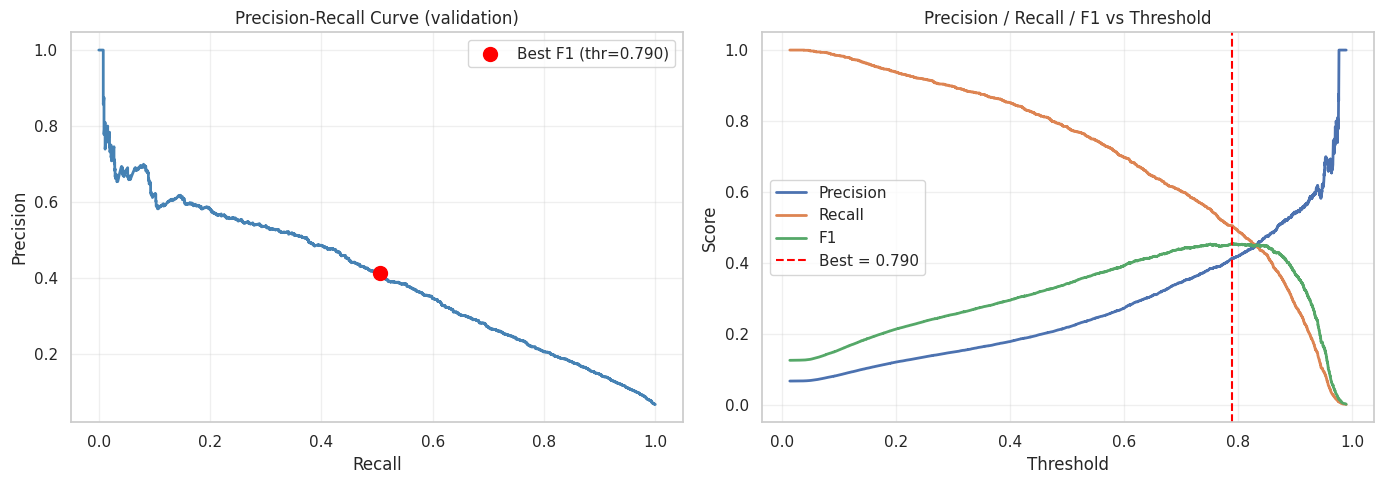

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Индекс лучшего F1 среди точек, которым соответствует threshold
best_idx = f1[:-1].argmax()
best_thr = thresholds[best_idx]

# PR-кривая
axes[0].plot(recalls, precisions, linewidth=2, color="steelblue")
axes[0].scatter(
    recalls[best_idx],
    precisions[best_idx],
    color="red",
    s=100,
    zorder=5,
    label=f"Best F1 (thr={best_thr:.3f})"
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (validation)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Threshold plot
axes[1].plot(thresholds, precisions[:-1], label="Precision", linewidth=2)
axes[1].plot(thresholds, recalls[:-1], label="Recall", linewidth=2)
axes[1].plot(thresholds, f1[:-1], label="F1", linewidth=2)

axes[1].axvline(
    best_thr,
    color="red",
    linestyle="--",
    label=f"Best = {best_thr:.3f}"
)

axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 vs Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Оптимальный порог отсечения по F1 на validation — 0.790. При этом Precision = 0.413, Recall = 0.505, F1 = 0.454. Порог выбирается только на validation и затем фиксируется для итоговой оценки на test.

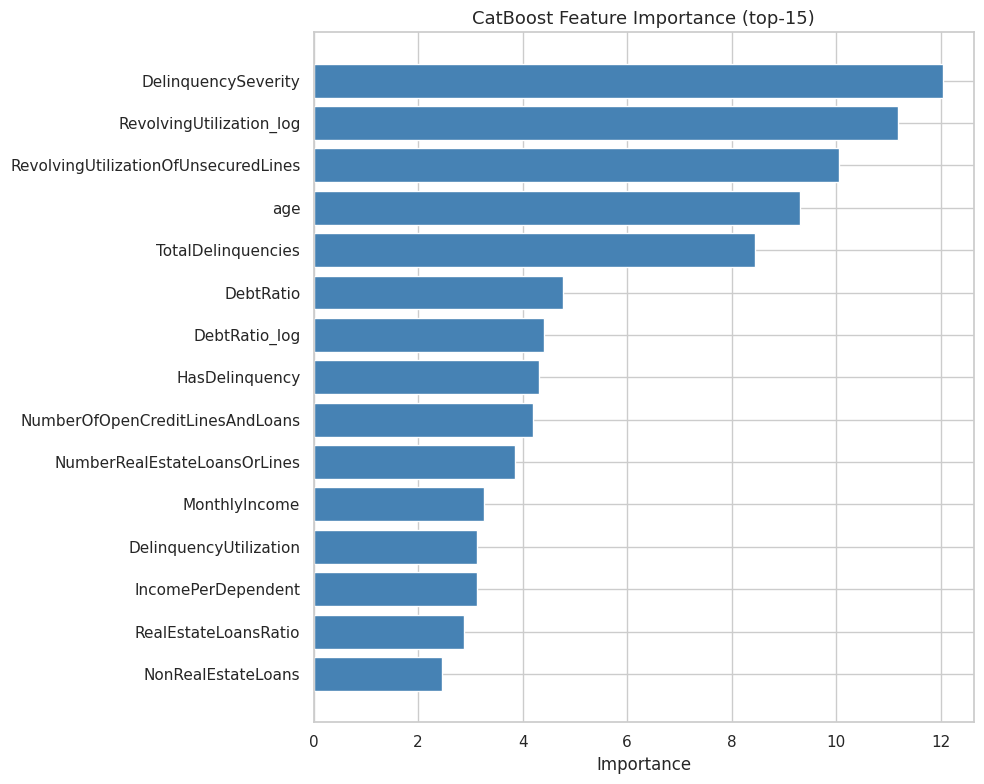

In [81]:
importance = pd.DataFrame({
    "feature": X_train_f.columns,
    "importance": best_model.get_feature_importance()
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(importance["feature"][::-1], importance["importance"][::-1],
         color="steelblue")
plt.title("CatBoost Feature Importance (top-15)", fontsize=13)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [82]:
import shap

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_f.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (5000, 28)


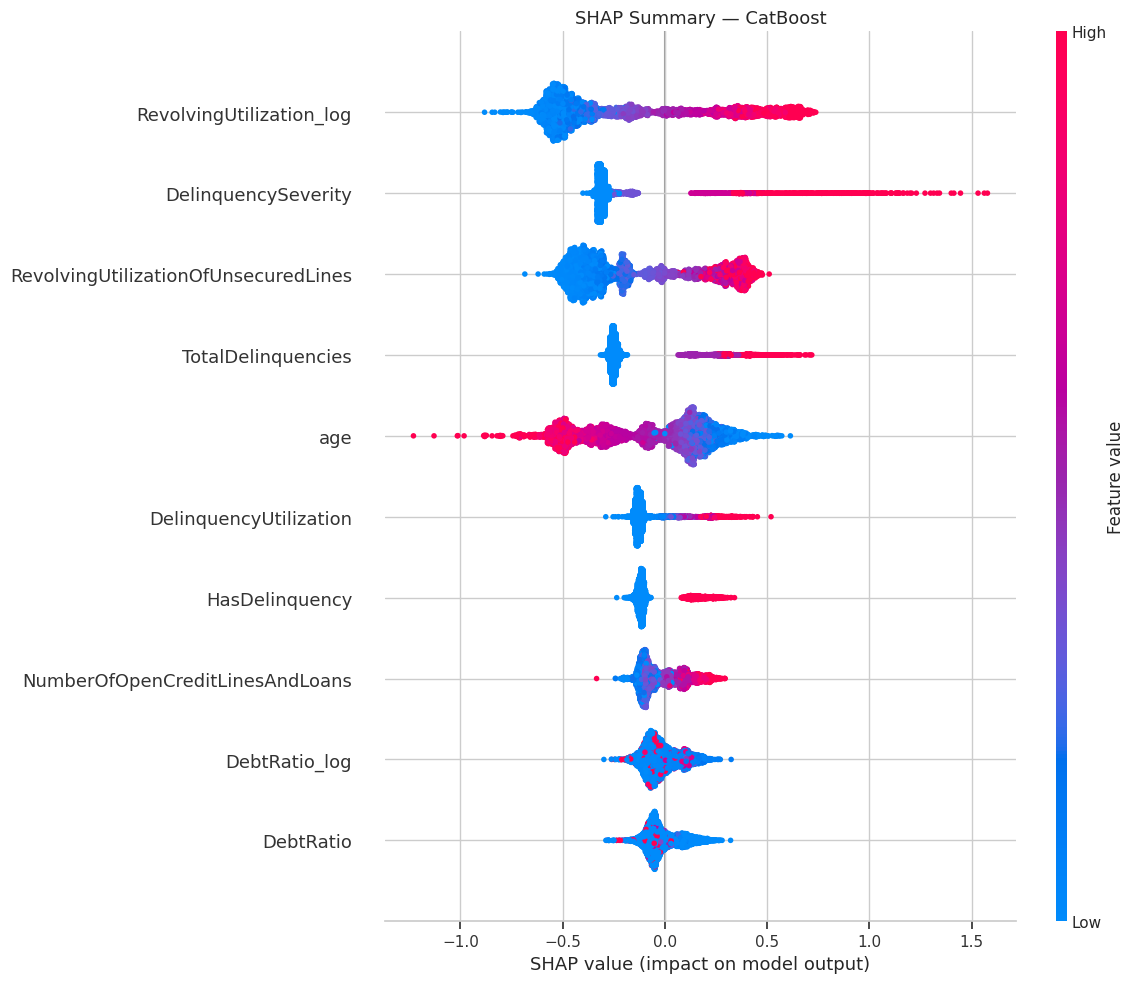

In [83]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    max_display=10,
    plot_size=(12,10),
    show=False
)
plt.title("SHAP Summary — CatBoost", fontsize=13)
plt.tight_layout()
plt.show()

топ SHAP совпадает с feature importance, но показывает направление и нелинейность. Модель опирается на утилизацию и историю просрочек - это соответствует бизнес-логике кредитного риска

In [102]:
# Находим показательного клиента:
# 30 лет, 9 просрочек, включая 5 просрочек 90+ дней,
# 4 иждивенца и реальный дефолт
test_results = X_test_f.copy()
test_results["actual_default"] = y_test.values
test_results["predicted_probability"] = y_test_proba

candidate_clients = test_results[
    (test_results["age"] == 30) &
    (
        test_results["NumberOfTime30-59DaysPastDueNotWorse"] +
        test_results["NumberOfTime60-89DaysPastDueNotWorse"] +
        test_results["NumberOfTimes90DaysLate"]
        == 9
    ) &
    (test_results["NumberOfTimes90DaysLate"] == 5) &
    (test_results["NumberOfDependents"] == 4) &
    (test_results["actual_default"] == 1)
]

print(f"Найдено подходящих клиентов: {len(candidate_clients)}")

if len(candidate_clients) > 0:
    interesting_client_id = candidate_clients[
        "predicted_probability"
    ].idxmax()

    interesting_client = test_results.loc[interesting_client_id]

    print(f"Client ID: {interesting_client_id}")
    print(f"Actual default: {interesting_client['actual_default']}")
    print(
        f"Model score: "
        f"{interesting_client['predicted_probability']:.3f}"
    )

    display(
        interesting_client
        .drop(["actual_default", "predicted_probability"])
        .to_frame("value")
    )

else:
    print("Подходящий клиент не найден.")

Найдено подходящих клиентов: 1
Client ID: 11724
Actual default: 1.0
Model score: 0.980


,value
RevolvingUtilizationOfUnsecuredLines,1.009463
age,30.000000
NumberOfTime30-59DaysPastDueNotWorse,2.000000
DebtRatio,0.570130
MonthlyIncome,3300.000000
NumberOfOpenCreditLinesAndLoans,11.000000
NumberOfTimes90DaysLate,5.000000
NumberRealEstateLoansOrLines,0.000000
NumberOfTime60-89DaysPastDueNotWorse,2.000000
NumberOfDependents,4.000000


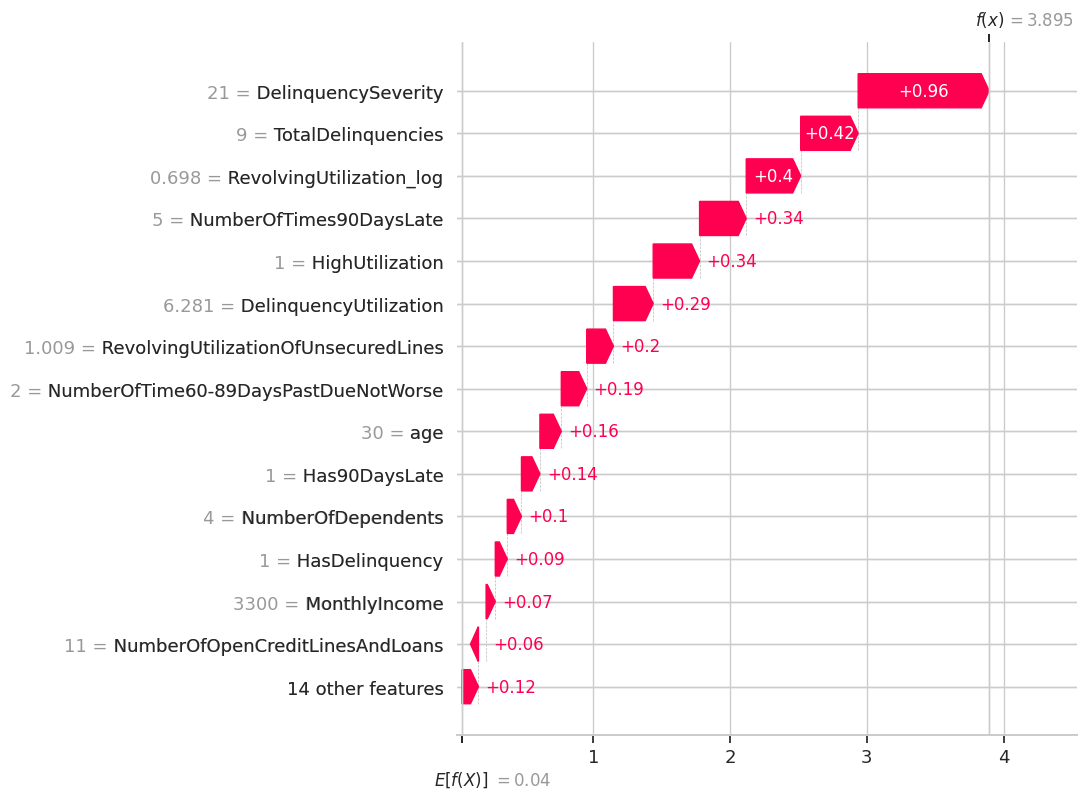

In [94]:
# SHAP waterfall для показательного клиента

explainer = shap.TreeExplainer(best_model)

client_data = X_test_f.loc[[interesting_client_id]]
client_shap = explainer(client_data)

shap.plots.waterfall(client_shap[0], max_display=15)

###Интерпретация

Для интерпретации выбран реальный клиент из test set с фактическим дефолтом: возраст 30 лет, 9 просрочек, включая 5 просрочек 90+ дней, и 4 иждивенца.

Глобальная SHAP-важность в целом согласуется с встроенной feature importance модели: наиболее значимыми признаками являются показатели просрочек, кредитной нагрузки и использования кредитных линий.

В отличие от обычной feature importance, SHAP позволяет дополнительно увидеть направление и величину вклада признака в предсказание. Например, высокие значения некоторых delinquency-related признаков в отдельных наблюдениях увеличивают model output в сторону более высокого риска.

Важно, что SHAP описывает поведение обученной модели и не является доказательством причинно-следственной связи. Поэтому результаты следует интерпретировать как объяснение предсказаний модели, а не как утверждение о том, что конкретный фактор сам по себе вызывает дефолт.


# KS-критерий

In [91]:
from scipy.stats import ks_2samp

#Вероятности на test
y_test_proba = best_model.predict_proba(X_test_f)[:, 1]

ks_stat, p_value = ks_2samp(
    y_test_proba[y_test == 1],
    y_test_proba[y_test == 0]
)

print(f"KS = {ks_stat:.4f}, p-value = {p_value:.2e}")

KS = 0.5745, p-value = 0.00e+00


### KS statistic

Для дополнительной оценки разделяющей способности модели был рассчитан Kolmogorov–Smirnov (KS) statistic.

**KS = 0.575**, что показывает существенное разделение score distributions между клиентами с дефолтом и без дефолта.

KS statistic определяется как максимальная абсолютная разница между эмпирическими cumulative distribution functions model scores для двух классов.

В credit scoring KS часто используется как дополнительная метрика способности модели разделять классы. В данном проекте он используется вместе с ROC-AUC и PR-AUC, а не вместо них.

Полученное `p-value ≈ 0` означает, что распределения score статистически различаются, но само по себе не является показателем качества модели и поэтому отдельно не интерпретируется.
